In [1]:
import scipy.stats as stats  # SciPy statistics package
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(1234)  # Set a fixed seed so everyone sees the same random results.
plt.style.use("seaborn-v0_8-whitegrid")

# Using SciPy Stats for Discrete Probability Distributions

The SciPy Stats package allows us to work with many parametric probability distributions. We can simulate random samples, compute probability mass functions (PMFs), and calculate cumulative distribution functions (CDFs).

In this notebook, you will explore four important discrete distributions from this course:

1. Binomial
2. Geometric
3. Negative Binomial
4. Poisson

## Repeated Learning Structure

Each distribution section follows the same flow so you can compare methods across cases:

1. **Introduce the distribution** (what it models and why it is useful).
2. **Simulate random variables** with SciPy.
3. **Visualize and interpret the PMF**.
4. **Connect to atmospheric science applications**.

By the end, you should be able to:

- identify when each distribution is appropriate,
- simulate random variables in Python, and
- compare simulated results to theoretical behavior.

# Discrete Distributions
---
## 1. Binomial Distribution

This is one of the simplest parametric distributions and is often used to introduce discrete probability models.

The binomial distribution describes the number of successes in $N$ independent trials, where each trial has the same probability of success $p$.

Examples of two outcomes are "success"/"failure", "rain"/"no rain", or "truth"/"lie".

#### How it works:
- One event is coded as 1 (success) and the other as 0 (failure).
- A random variable $X$ is the number of successes in $N$ trials.
- The success probability is $p$.
- $N$ can be any positive integer.
- $X$ can take values from 0 to $N$.

This distribution gives probabilities for each of the $N + 1$ possible values of $X$, under two key assumptions:

1. The success probability $p$ is constant from trial to trial.
2. Trials are mutually independent.

### Atmospheric Applications

- Number of rainy days in a 2-week period.
- Number of days with temperature above a threshold in a month.
- Number of storm reports in a fixed set of forecast periods when each period is treated as yes/no.

These are binomial-style problems when the number of trials is fixed and the success probability is approximately constant.

### Simulate Random Variables

Generate synthetic realizations from a binomial model, then inspect summary statistics and the histogram.

In [2]:
N = 100
p = 0.6

df = stats.binom.rvs(n=N, p=p, size=100)
binomial_dist = pd.DataFrame(df)
binomial_dist

,0
0,61
1,54
2,61
3,52
4,57
...,...
95,56
96,60
97,59
98,69


With the data in a DataFrame, we can apply EDA-type functions like describe() to understand more about the data.

In [3]:
binomial_dist.describe()

,0
count,100.000000
mean,60.020000
std,4.385421
min,51.000000
25%,57.750000
50%,60.500000
75%,63.000000
max,69.000000


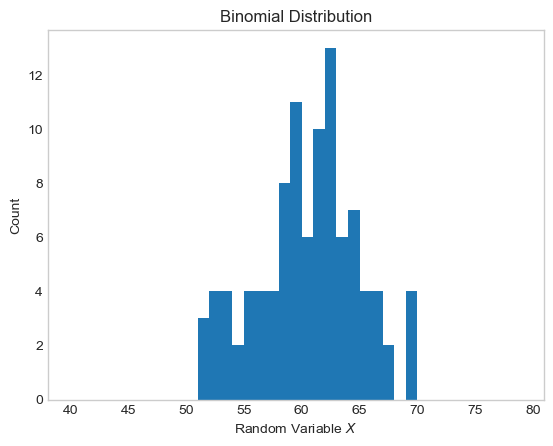

In [4]:
plt.title("Binomial Distribution")
plt.hist(binomial_dist, bins=np.arange(40,80))
plt.grid()
plt.ylabel("Count")
plt.xlabel("Random Variable $X$")
plt.show()

### Probability Mass Function (PMF)

For the binomial distribution, the PMF gives the probability of exactly $x$ successes in $N$ trials:

$$P(X=x) = {N\choose x} p^x (1-p)^{N-x}, \quad x=0,1,\ldots,N$$

Use the PMF plot below to compare the most likely outcomes with the simulated histogram above.

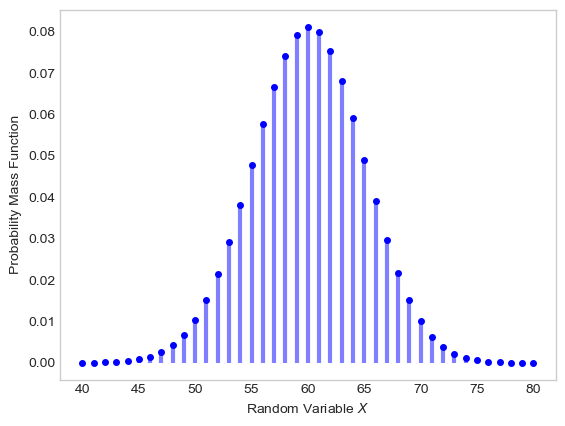

In [5]:
x = np.arange(40,81,1)
pmf = stats.binom.pmf(x, n=N, p=p)

plt.plot(x, pmf, 'bo', ms=4)
plt.vlines(x, 0, pmf, colors='b', lw=3, alpha=0.5)
plt.ylabel("Probability Mass Function")
plt.xlabel("Random Variable $X$")
plt.grid()
plt.show()

## 2. Geometric Distribution

The geometric distribution is related to the binomial distribution, but answers a different question.

Instead of counting how many successes occur in a fixed number of trials, it counts how many trials are needed to get the **first** success.

For weather applications, this can represent waiting times or spell lengths, such as the number of dry periods before the next wet period.

### Atmospheric Applications

- Number of days until the first thunderstorm in a season.
- Number of forecast cycles until the next rain event.
- Number of dry periods before a wet period.

These are geometric-style problems when you are waiting for the **first** success.

### Simulate Random Variables

Generate realizations of waiting times until the first success and inspect how quickly frequencies decay.

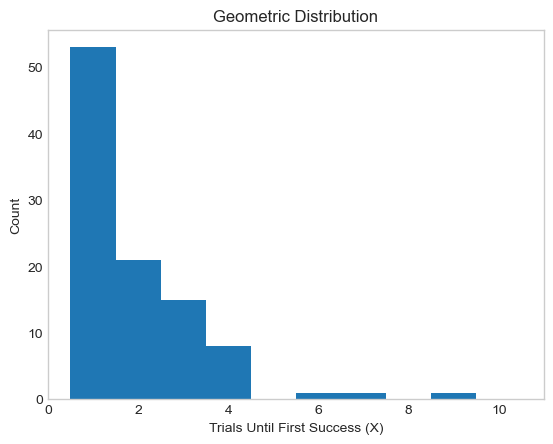

In [6]:
df = stats.geom.rvs(p=0.6, size=100)
geometric_dist = pd.DataFrame(df, columns=["X"] )

plt.title("Geometric Distribution")
plt.hist(geometric_dist["X"], bins=np.arange(1, 12) - 0.5)
plt.grid()
plt.ylabel("Count")
plt.xlabel("Trials Until First Success (X)")
plt.show()

### Probability Mass Function (PMF)

For the geometric distribution, the PMF gives the probability that the **first success** happens on trial $x$:

$$P(X=x) = (1-p)^{x-1}p, \quad x=1,2,3,\ldots$$

Compare the steep drop in PMF values with your simulation histogram.

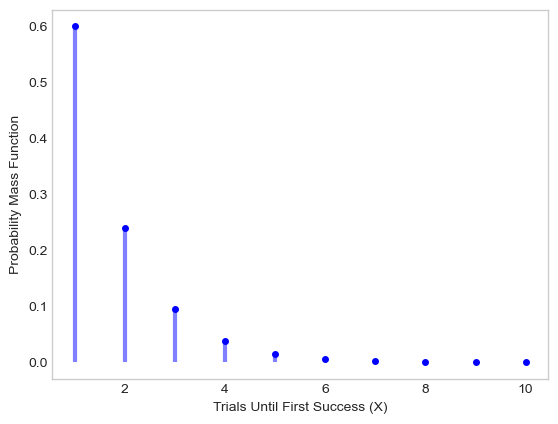

In [7]:
x = np.arange(1, 11, 1)
pmf = stats.geom.pmf(x, p=0.6)

plt.plot(x, pmf, 'bo', ms=4)
plt.vlines(x, 0, pmf, colors='b', lw=3, alpha=0.5)
plt.ylabel("Probability Mass Function")
plt.xlabel("Trials Until First Success (X)")
plt.grid()
plt.show()

## 3. Negative Binomial Distribution

The negative binomial distribution is a generalization of the geometric distribution.

Where the geometric distribution asks for waiting time until the first success, the negative binomial asks for waiting time until the $N$th success.

SciPy's parameterization uses:

- $N$: number of successes required
- $p$: probability of success on each trial
- random variable $k$: number of failures before reaching $N$ successes

### Atmospheric Applications

- Number of non-rainy days before the 4th rainy day.
- Number of non-severe days before the 2nd severe thunderstorm day.
- Number of low-visibility mornings before a target count of fog events.

These are negative-binomial-style problems when you wait for the $N$-th success and count failures along the way.

### Simulate Random Variables

Generate synthetic values for failures before reaching a fixed number of successes.

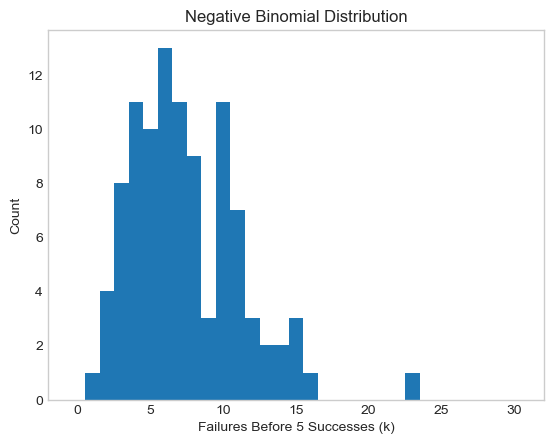

In [8]:
N = 5  # Number of successes needed
p = 0.4  # Probability of a single success

df = stats.nbinom.rvs(n=N, p=p, size=100)
neg_binom_dist = pd.DataFrame(df, columns=["k"] )

plt.title("Negative Binomial Distribution")
plt.hist(neg_binom_dist["k"], bins=np.arange(0, 32) - 0.5)
plt.grid()
plt.ylabel("Count")
plt.xlabel("Failures Before 5 Successes (k)")
plt.show()

### Probability Mass Function (PMF)

Now compute and plot the PMF to compare theory with the simulated histogram.

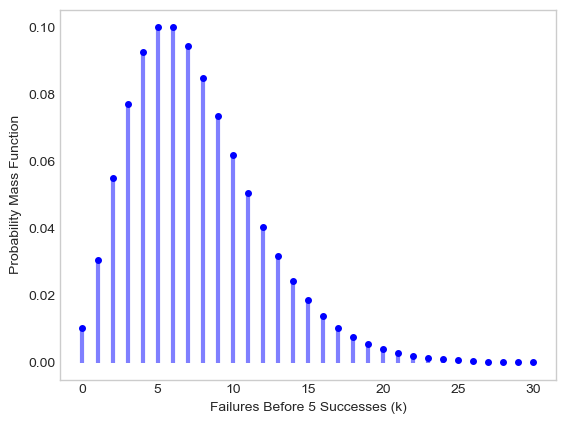

In [9]:
k = np.arange(0, 31, 1)  # Number of failures before N successes.
pmf = stats.nbinom.pmf(k=k, n=N, p=p)

plt.plot(k, pmf, 'bo', ms=4)
plt.vlines(k, 0, pmf, colors='b', lw=3, alpha=0.5)
plt.ylabel("Probability Mass Function")
plt.xlabel("Failures Before 5 Successes (k)")
plt.grid()
plt.show()

## 4. Poisson Distribution

The Poisson distribution describes the number of events occurring in a fixed interval of time or space.

It is used for count data where events occur independently and at a constant average rate $\mu$.

Examples include the number of emails arriving per minute, calls per hour, or defects per meter of material.

### Atmospheric Applications

- Number of lightning strikes per hour in a storm-prone region.
- Number of hail reports per county during a fixed time window.
- Number of cloud-to-ground strikes during a convective event segment.

These are Poisson-style problems when events are counted in fixed intervals with an approximately constant mean rate.

### Simulate Random Variables

Generate synthetic event counts for fixed intervals and compare histogram shape with the PMF.

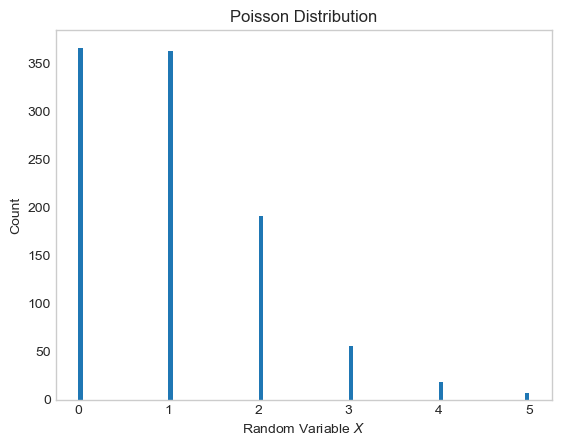

In [10]:
mu = 1
df = stats.poisson.rvs(mu, size=1000)
poisson_dist = pd.DataFrame(df)

plt.title("Poisson Distribution")
plt.hist(poisson_dist, 100)
plt.grid()
plt.ylabel("Count")
plt.xlabel("Random Variable $X$")
plt.show()

### Probability Mass Function (PMF)

For the Poisson distribution, the PMF is

$$P(X=x) = \frac{\mu^x e^{-\mu}}{x!}, \quad x=0,1,2,\ldots$$

This shows how likely each event count is for a fixed interval when the mean rate is $\mu$.

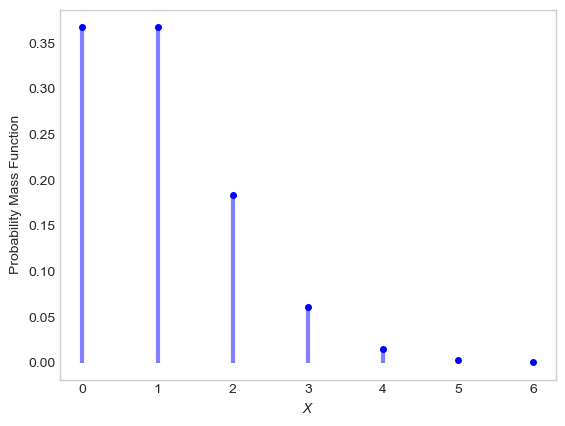

In [11]:
x = np.arange(0,7,1) # number of failures before N successes.
pmf = stats.poisson.pmf(x, mu=mu)

plt.plot(x, pmf, 'bo', ms=4)
plt.vlines(x, 0, pmf, colors='b', lw=3, alpha=0.5)
plt.ylabel("Probability Mass Function")
plt.xlabel("$X$")
plt.grid()
plt.show()

### Key Takeaways

- **Binomial**: number of successes in a fixed number of trials.
- **Geometric**: number of trials needed for the first success.
- **Negative Binomial**: number of failures before a target number of successes.
- **Poisson**: number of events in a fixed interval when events occur at rate $\mu$.

As sample size increases, simulated statistics approach theoretical values (law of large numbers).

In [13]:
n_samples = 5000

summary = []

# Binomial
N_binom, p_binom = 100, 0.6
sim_binom = stats.binom.rvs(n=N_binom, p=p_binom, size=n_samples)
summary.append({
    "Distribution": "Binomial",
    "Simulated Mean": np.mean(sim_binom),
    "Theoretical Mean": N_binom * p_binom,
    "Simulated Variance": np.var(sim_binom),
    "Theoretical Variance": N_binom * p_binom * (1 - p_binom),
})

# Geometric (SciPy parameterization: trials until first success, support starts at 1)
p_geom = 0.6
sim_geom = stats.geom.rvs(p=p_geom, size=n_samples)
summary.append({
    "Distribution": "Geometric",
    "Simulated Mean": np.mean(sim_geom),
    "Theoretical Mean": 1 / p_geom,
    "Simulated Variance": np.var(sim_geom),
    "Theoretical Variance": (1 - p_geom) / (p_geom ** 2),
})

# Negative Binomial (SciPy parameterization: failures before N successes)
N_nbinom, p_nbinom = 5, 0.4
sim_nbinom = stats.nbinom.rvs(n=N_nbinom, p=p_nbinom, size=n_samples)
summary.append({
    "Distribution": "Negative Binomial",
    "Simulated Mean": np.mean(sim_nbinom),
    "Theoretical Mean": N_nbinom * (1 - p_nbinom) / p_nbinom,
    "Simulated Variance": np.var(sim_nbinom),
    "Theoretical Variance": N_nbinom * (1 - p_nbinom) / (p_nbinom ** 2),
})

# Poisson
mu_pois = 1
sim_pois = stats.poisson.rvs(mu=mu_pois, size=n_samples)
summary.append({
    "Distribution": "Poisson",
    "Simulated Mean": np.mean(sim_pois),
    "Theoretical Mean": mu_pois,
    "Simulated Variance": np.var(sim_pois),
    "Theoretical Variance": mu_pois,
})

summary_df = pd.DataFrame(summary)
summary_df.round(3)

,Distribution,Simulated Mean,Theoretical Mean,Simulated Variance,Theoretical Variance
0,Binomial,59.916,60.000,23.783,24.000
1,Geometric,1.694,1.667,1.206,1.111
2,Negative Binomial,7.637,7.500,18.850,18.750
3,Poisson,0.963,1.000,0.950,1.000


## 6. Student Exercises

Apply the discrete distributions from this notebook to realistic atmospheric science scenarios.

### Exercise 1: Binomial (Daily Rain/No-Rain)
A station has a 30% chance of measurable rain on any day in summer. Assume day-to-day independence.

1. Let $X$ be the number of rainy days in a 14-day period. What distribution does $X$ follow?
2. Compute $P(X = 5)$.
3. Compute $P(X \geq 8)$.
4. Simulate 10,000 two-week periods and compare simulated vs theoretical mean.

### Exercise 2: Geometric (Waiting Time to First Thunderstorm)
Suppose the probability of a thunderstorm on a given afternoon is $p = 0.2$.

> Use SciPy's geometric definition: $X$ = number of trials until first success (support starts at 1).

1. Compute $P(X = 4)$.
2. Compute $P(X \leq 3)$.
3. Simulate 5,000 realizations and compare the sample mean to $1/p$.

### Exercise 3: Negative Binomial (Failures Before Target Successes)
A forecaster tracks days with fog. Let a "success" be a fog day with probability $p=0.25$ and define $k$ as non-fog days before the 3rd fog day.

1. Identify the correct distribution and parameters.
2. Compute $P(k = 6)$.
3. Compute $P(k \leq 10)$.
4. Simulate and compare theoretical and simulated variance.

### Exercise 4: Poisson (Lightning Strikes per Hour)
In a region, lightning strikes occur at an average rate of $\mu = 2.3$ strikes per hour.

1. Compute $P(X = 0)$ in one hour.
2. Compute $P(X \geq 5)$ in one hour.
3. Over 1,000 simulated hours, compare the sample mean and variance with Poisson theory.

### Discussion Prompt
For each exercise, briefly state why your chosen distribution is appropriate in terms of trial structure, independence assumptions, and interpretation of the random variable.

In [14]:
# Optional starter code for the exercises above
exercise_results = {}

# Exercise 1 example structure (Binomial)
n_days = 14
p_rain = 0.30
exercise_results["ex1_p_x_eq_5"] = stats.binom.pmf(5, n=n_days, p=p_rain)
exercise_results["ex1_p_x_ge_8"] = 1 - stats.binom.cdf(7, n=n_days, p=p_rain)

sim_ex1 = stats.binom.rvs(n=n_days, p=p_rain, size=10_000)
exercise_results["ex1_sim_mean"] = np.mean(sim_ex1)
exercise_results["ex1_theory_mean"] = n_days * p_rain

# Exercise 4 example structure (Poisson)
mu_lightning = 2.3
exercise_results["ex4_p_x_eq_0"] = stats.poisson.pmf(0, mu=mu_lightning)
exercise_results["ex4_p_x_ge_5"] = 1 - stats.poisson.cdf(4, mu=mu_lightning)

sim_ex4 = stats.poisson.rvs(mu=mu_lightning, size=1_000)
exercise_results["ex4_sim_mean"] = np.mean(sim_ex4)
exercise_results["ex4_sim_variance"] = np.var(sim_ex4)

pd.Series(exercise_results).round(4)

ex1_p_x_eq_5        0.1963
ex1_p_x_ge_8        0.0315
ex1_sim_mean        4.1736
ex1_theory_mean     4.2000
ex4_p_x_eq_0        0.1003
ex4_p_x_ge_5        0.0838
ex4_sim_mean        2.2720
ex4_sim_variance    2.3560
dtype: float64